# TinyML Gesture Recognition — Train & Deploy

**Companion to the Nano 33 BLE Sense TinyML lab.**

By the end of this notebook you will have:
1. Loaded pre-recorded `punch` and `flex` gesture data (no data collection needed).
2. Trained a small dense network in Keras.
3. Converted it to TensorFlow Lite and quantized it to int8.
4. Exported it as a C header (`model.h`) that you drop into the Arduino sketch.

**Total runtime:** ~2 minutes on free Colab.

---


## 0. Setup

Colab already has TensorFlow installed. We just import what we need.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print('TensorFlow version:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0


## 1. Download the pre-recorded gesture data

We use the standard Arduino punch/flex CSVs. Each file contains many
1-second gesture samples in the format:

```
aX,aY,aZ,gX,gY,gZ
<119 rows per sample>
<blank line separates samples>
```

**Instructor note:** if the URL below stops resolving, host a mirror of
the two CSVs anywhere reachable and replace `DATA_URL_BASE` accordingly.

In [ ]:
DATA_URL_BASE = 'https://raw.githubusercontent.com/arduino/ArduinoTensorFlowLiteTutorials/master/GestureToEmoji/'

# Fallback mirrors in case the primary URL is unavailable.
MIRRORS = [
    DATA_URL_BASE,
    'https://raw.githubusercontent.com/devnithw/gesture-tinyml/main/data/',
]

GESTURES = ['punch', 'flex']  # ← order matters; the Arduino sketch must match

for gesture in GESTURES:
    for base in MIRRORS:
        url = base + gesture + '.csv'
        rc = os.system(f'wget -q -O {gesture}.csv {url}')
        if rc == 0 and os.path.getsize(gesture + '.csv') > 1000:
            print(f'Downloaded {gesture}.csv from {base}')
            break
    else:
        raise RuntimeError(f'Could not download {gesture}.csv from any mirror.')

!ls -la *.csv

Downloaded punch.csv from https://raw.githubusercontent.com/devnithw/gesture-tinyml/main/data/
Downloaded flex.csv from https://raw.githubusercontent.com/devnithw/gesture-tinyml/main/data/
-rw-r--r-- 1 root root 50636 May 14 08:24 flex.csv
-rw-r--r-- 1 root root 50578 May 14 08:24 punch.csv


## 2. Visualize one example of each gesture

Before training, let's *look* at what the model has to learn. Plotting one
sample of each gesture builds intuition — and is also the fastest sanity
check that the data downloaded correctly.

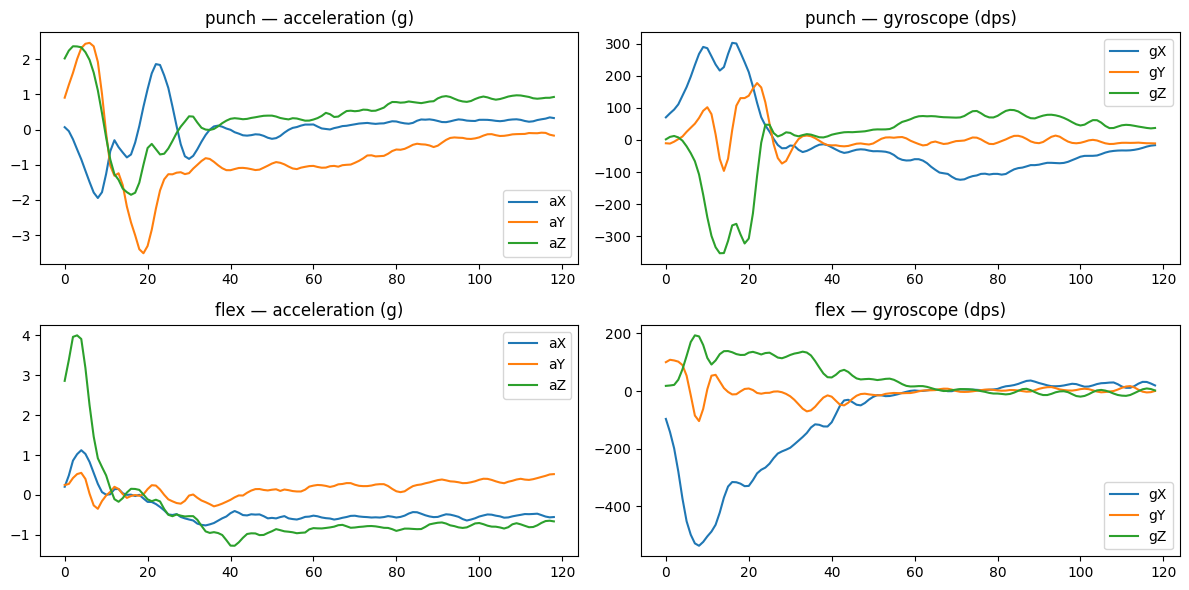

In [ ]:
def load_first_sample(csv_path):
    """Return the first 119-row sample from a gesture CSV as a DataFrame."""
    df = pd.read_csv(csv_path)
    # The CSV uses blank lines to separate samples; pandas read_csv with the
    # default settings strips them. For the visualization we just take the
    # first 119 rows.
    return df.iloc[:119]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, g in enumerate(GESTURES):
    s = load_first_sample(g + '.csv')
    axes[i, 0].plot(s[['aX','aY','aZ']].values)
    axes[i, 0].set_title(f'{g} — acceleration (g)')
    axes[i, 0].legend(['aX','aY','aZ'])
    axes[i, 1].plot(s[['gX','gY','gZ']].values)
    axes[i, 1].set_title(f'{g} — gyroscope (dps)')
    axes[i, 1].legend(['gX','gY','gZ'])
plt.tight_layout()
plt.show()

## 3. Parse & normalize

Each gesture sample is 119 timesteps × 6 channels = **714 features**. We:
1. Slice the long CSV into individual 119-row samples.
2. Normalize accel to `[0, 1]` (was `[-4, 4] g`).
3. Normalize gyro to `[0, 1]` (was `[-2000, 2000] dps`).
4. Flatten each sample to a 1-D vector for the dense network.

**⚠️ The Arduino sketch performs the exact same normalization. If you
change one, you must change the other.**

In [ ]:
SAMPLES_PER_GESTURE = 119
NUM_CHANNELS = 6  # aX,aY,aZ,gX,gY,gZ

ONE_HOT = np.eye(len(GESTURES))

inputs = []
outputs = []

for gi, g in enumerate(GESTURES):
    df = pd.read_csv(g + '.csv')
    # Drop any all-NaN rows that pandas may have introduced from blank lines.
    df = df.dropna().reset_index(drop=True)
    n_samples = len(df) // SAMPLES_PER_GESTURE
    print(f'  {g}: {n_samples} samples ({len(df)} rows)')

    for s in range(n_samples):
        block = df.iloc[s*SAMPLES_PER_GESTURE : (s+1)*SAMPLES_PER_GESTURE].values
        # block.shape == (119, 6)
        # Normalize accel (cols 0..2) and gyro (cols 3..5).
        norm = np.empty_like(block)
        norm[:, 0:3] = (block[:, 0:3] + 4.0)    / 8.0
        norm[:, 3:6] = (block[:, 3:6] + 2000.0) / 4000.0
        inputs.append(norm.flatten())
        outputs.append(ONE_HOT[gi])

inputs  = np.array(inputs,  dtype=np.float32)
outputs = np.array(outputs, dtype=np.float32)
print()
print('inputs.shape :', inputs.shape)   # (n_total, 714)
print('outputs.shape:', outputs.shape)  # (n_total, n_gestures)

  punch: 10 samples (1190 rows)
  flex: 10 samples (1190 rows)

inputs.shape : (20, 714)
outputs.shape: (20, 2)


## 4. Shuffle and split (60 / 20 / 20)

In [ ]:
n = len(inputs)
perm = np.random.permutation(n)
inputs, outputs = inputs[perm], outputs[perm]

t1 = int(0.6 * n)
t2 = int(0.8 * n)
X_train, X_val, X_test = inputs[:t1], inputs[t1:t2], inputs[t2:]
y_train, y_val, y_test = outputs[:t1], outputs[t1:t2], outputs[t2:]

print(f'train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}')

train: 12   val: 4   test: 4


## 5. Build a small dense network

Three fully-connected layers. ReLU activations, softmax output. Roughly
**12 K parameters** — small enough to fit comfortably on the Nano's 1 MB
of flash even before quantization.

In [ ]:
model = tf.keras.Sequential([
    #todo: add the layers here
    tf.keras.layers.Dense(16, activation='relu', input_shape=(714,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(len(GESTURES), activation='softmax'),
])


model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'],
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │        35,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           765 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            32 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,547 (142.76 KB)

 Trainable params: 36,547 (142.76 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=600,
    batch_size=1,
    validation_data=(X_val, y_val),
    verbose=0,
)
print('Done.')

Done.


## 8. Convert to TensorFlow Lite
We convert the trained Keras model to TFLite **twice**:
1. Plain float32.
2. With **post-training int8 quantization** — every weight and activation
   becomes an 8-bit integer.

Watch the file sizes.

In [ ]:
# --- 1. Plain float conversion ---
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float = converter.convert()
open('gesture_model.tflite', 'wb').write(tflite_float)

# --- 2. Int8 quantization ---
def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

#todo: add the converter_q code to quantize both weights and activations
converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]




tflite_quant = converter_q.convert()
open('gesture_model_quant.tflite', 'wb').write(tflite_quant)

float_size = len(tflite_float)
quant_size = len(tflite_quant)
print(f'Float32 model:   {float_size:>7d} bytes  ({float_size/1024:.1f} KB)')
print(f'Quantized model: {quant_size:>7d} bytes  ({quant_size/1024:.1f} KB)')
print(f'Compression:     {float_size/quant_size:.2f}x smaller')

Saved artifact at '/tmp/tmpxosy1e4m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137073288677328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073288678480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073288677136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073288675984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073288679056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137073288675792: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmpg1xabx2v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137073288677328: TensorSpe

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 9. Export as a C header (`model.h`)

In [ ]:
MODEL_TFLITE = "gesture_model_quant.tflite"
MODEL_TFLITE_MICRO = "model.h"

In [ ]:
# Convert binary → C array using xxd, add const for flash storage
!xxd -i {MODEL_TFLITE} | sed 's/unsigned char/const unsigned char/g' > {MODEL_TFLITE_MICRO}

# Download to put alongside the .ino sketch
from google.colab import files
files.download(MODEL_TFLITE_MICRO)